In [1]:
print("Hello Jupyter")



Hello Jupyter


In [3]:
pip install pandas matplotlib seaborn


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("hello")


hello


In [37]:

import pandas as pd
df=pd.read_csv("Hotels Booking Data.csv")
df.head()

df.columns


df.describe(include='all')
df.isnull().sum()
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['check_in_date'] = pd.to_datetime(df['check_in_date'])
df['check_out_date'] = pd.to_datetime(df['check_out_date'])
df['travel_date'] = pd.to_datetime(df['travel_date'])
df.dtypes
df.isnull().sum()






customer_id              0
property_id              0
city                     0
star_rating              0
booking_date             0
check_in_date         5468
check_out_date        5468
room_type                0
num_rooms_booked         0
stay_type                0
booking_channel          0
booking_value            0
costprice                0
markup                   0
selling_price            0
payment_method           0
refund_status            0
refund_amount            0
channel_of_booking       0
booking_status           0
travel_date              0
cashback                 0
coupon_redeem            0
Coupon USed?             0
length_of_stay        5468
is_weekend_checkin       0
dtype: int64

In [21]:
df.dtypes


customer_id                    int64
property_id                    int64
city                          object
star_rating                    int64
booking_date          datetime64[ns]
check_in_date         datetime64[ns]
check_out_date        datetime64[ns]
room_type                     object
num_rooms_booked               int64
stay_type                     object
booking_channel               object
booking_value                float64
costprice                      int64
markup                       float64
selling_price                float64
payment_method                object
refund_status                 object
refund_amount                float64
channel_of_booking            object
booking_status                object
travel_date           datetime64[ns]
cashback                     float64
coupon_redeem                float64
Coupon USed?                  object
length_of_stay               float64
is_weekend_checkin              bool
dtype: object

In [22]:
# Booking counts
print(df['booking_status'].value_counts())

# Cancellation rate
cancellation_rate = df['booking_status'].value_counts(normalize=True).get('Cancelled', 0) * 100
print(f"Cancellation Rate: {cancellation_rate:.2f}%")


booking_status
Confirmed    21963
Cancelled     5779
Failed        2258
Name: count, dtype: int64
Cancellation Rate: 19.26%


In [23]:
df['channel_of_booking'].value_counts()


channel_of_booking
Web        16023
Android     9505
iOS         4472
Name: count, dtype: int64

In [24]:
channel_cancellation = df.groupby('channel_of_booking')['booking_status'].apply(lambda x: (x=='Cancelled').mean()*100)
print(channel_cancellation)


channel_of_booking
Android    19.410836
Web        18.916557
iOS        20.192308
Name: booking_status, dtype: float64


In [25]:
df['room_type'].value_counts()


room_type
Standard    16552
Deluxe      10478
Suite        2970
Name: count, dtype: int64

In [26]:
room_cancellation = df.groupby('room_type')['booking_status'].apply(lambda x: (x=='Cancelled').mean()*100)
print(room_cancellation)


room_type
Deluxe      15.699561
Standard    22.124215
Suite       15.892256
Name: booking_status, dtype: float64


In [27]:
df['star_rating'].value_counts().sort_index()


star_rating
2     2995
3    10460
4    12034
5     4511
Name: count, dtype: int64

In [28]:
star_cancellation = df.groupby('star_rating')['booking_status'].apply(lambda x: (x=='Cancelled').mean()*100)
print(star_cancellation)


star_rating
2    19.966611
3    20.420650
4    18.140269
5    19.108845
Name: booking_status, dtype: float64


In [29]:
stay_cancellation = df.groupby('stay_type')['booking_status'].apply(lambda x: (x=='Cancelled').mean()*100)
print(stay_cancellation)


stay_type
Business    17.44323
Leisure     20.45831
Name: booking_status, dtype: float64


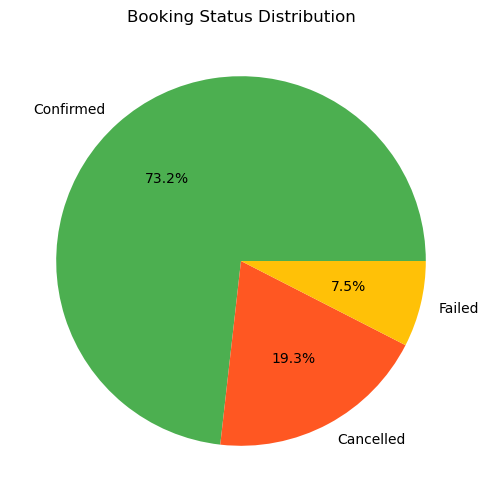

In [30]:
import matplotlib.pyplot as plt

# Pie chart for booking status
status_counts = df['booking_status'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['#4CAF50','#FF5722','#FFC107'])
plt.title('Booking Status Distribution')
plt.show()


C:\Users\igaur\AppData\Local\Temp\ipykernel_31272\1836777365.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=channel_cancellation.index, y=channel_cancellation.values, palette='Set2')


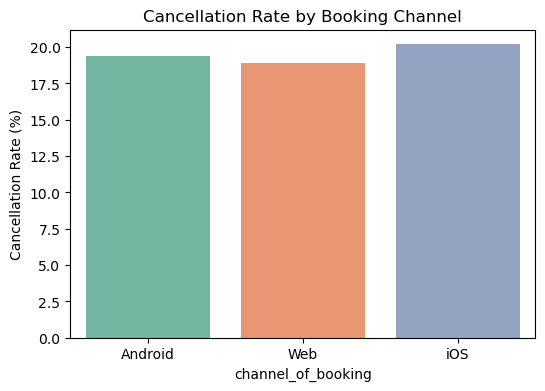

C:\Users\igaur\AppData\Local\Temp\ipykernel_31272\1836777365.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=room_cancellation.values, y=room_cancellation.index, palette='Set1', orient='h')


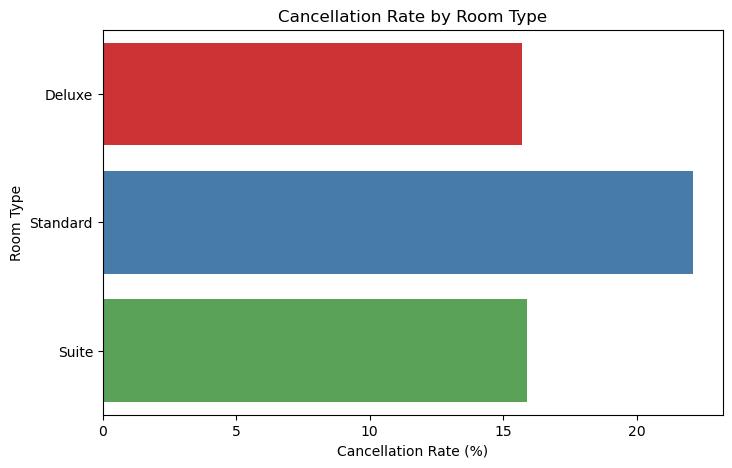

C:\Users\igaur\AppData\Local\Temp\ipykernel_31272\1836777365.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=star_cancellation.index, y=star_cancellation.values, palette='coolwarm')


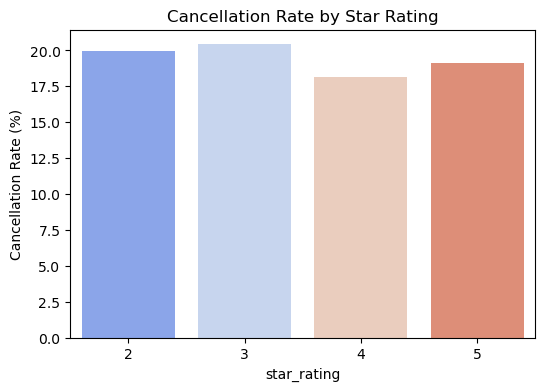

C:\Users\igaur\AppData\Local\Temp\ipykernel_31272\1836777365.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stay_cancellation.index, y=stay_cancellation.values, palette='pastel')


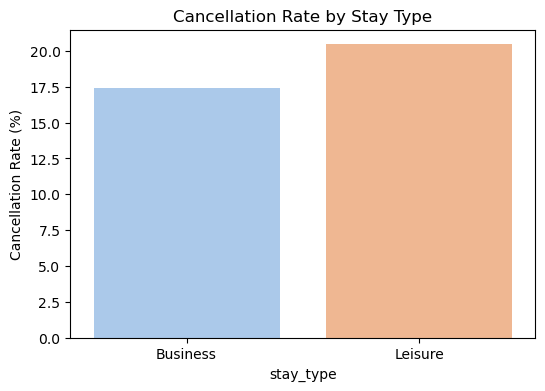

In [35]:

import seaborn as sns

# Cancellation rate by channel
plt.figure(figsize=(6,4))
sns.barplot(x=channel_cancellation.index, y=channel_cancellation.values, palette='Set2')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Booking Channel')
plt.show()

plt.figure(figsize=(8,5))  
sns.barplot(x=room_cancellation.values, y=room_cancellation.index, palette='Set1', orient='h')
plt.xlabel('Cancellation Rate (%)')
plt.ylabel('Room Type')
plt.title('Cancellation Rate by Room Type')
plt.show()

#Cancellation rate by star rating
plt.figure(figsize=(6,4))
sns.barplot(x=star_cancellation.index, y=star_cancellation.values, palette='coolwarm')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Star Rating')
plt.show()

# Cancellation rate by stay type
plt.figure(figsize=(6,4))
sns.barplot(x=stay_cancellation.index, y=stay_cancellation.values, palette='pastel')
plt.ylabel('Cancellation Rate (%)')
plt.title('Cancellation Rate by Stay Type')
plt.show()


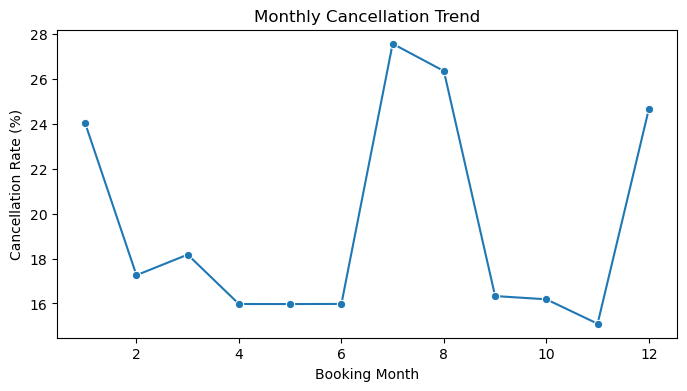

In [38]:

df['booking_month'] = df['booking_date'].dt.month

# Cancellation rate per month
monthly_cancellation = df.groupby('booking_month')['booking_status'].apply(lambda x: (x=='Cancelled').mean()*100)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
sns.lineplot(x=monthly_cancellation.index, y=monthly_cancellation.values, marker='o')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Booking Month')
plt.title('Monthly Cancellation Trend')
plt.show()
